# 08_lstm_autoencoder

Goals:
- load healthy and full CMAPSS anomaly sequences
- train an LSTM autoencoder
- compute reconstruction error for all sequences
- define an anomaly threshold
- evaluate anomaly detection performance

In [43]:


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [44]:
SEED = 9

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [45]:



PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
RESULTS_DIR = "../results"
PLOTS_DIR = "../plots/autoencoder"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 7

HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.0

DENOISING = False
NOISE_FACTOR = 0.00

EXPERIMENT_NAME = "lstm_autoencoder_strict_hidden32_mse"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [46]:


X_healthy = np.load(os.path.join(PROCESSED_DIR, "X_healthy_strict.npy"))
X_eval = np.load(os.path.join(PROCESSED_DIR, "X_eval_strict.npy"))
y_eval = np.load(os.path.join(PROCESSED_DIR, "y_eval_strict.npy"))

rul_eval = np.load(os.path.join(PROCESSED_DIR, "rul_eval_strict.npy"))
unit_eval = np.load(os.path.join(PROCESSED_DIR, "unit_eval_strict.npy"))
cycle_eval = np.load(os.path.join(PROCESSED_DIR, "cycle_eval_strict.npy"))

print("X_healthy:", X_healthy.shape)
print("X_eval:", X_eval.shape)
print("y_eval:", y_eval.shape)

print("Evaluation healthy:", np.sum(y_eval == 0))
print("Evaluation anomalies:", np.sum(y_eval == 1))

X_healthy: (4635, 30, 15)
X_eval: (4259, 30, 15)
y_eval: (4259,)
Evaluation healthy: 1159
Evaluation anomalies: 3100


In [47]:


SEQ_LENGTH = X_healthy.shape[1]
N_FEATURES = X_healthy.shape[2]

print("Sequence length:", SEQ_LENGTH)
print("Number of features:", N_FEATURES)

Sequence length: 30
Number of features: 15


In [48]:


X_healthy_tensor = torch.tensor(X_healthy, dtype=torch.float32)

healthy_dataset = TensorDataset(X_healthy_tensor, X_healthy_tensor)

train_size = int(0.8 * len(healthy_dataset))
val_size = len(healthy_dataset) - train_size

train_dataset, val_dataset = random_split(
    healthy_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train healthy sequences:", train_size)
print("Validation healthy sequences:", val_size)

Train healthy sequences: 3708
Validation healthy sequences: 927


In [49]:


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()

        self.n_features = n_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        _, (hidden, _) = self.encoder(x)

        latent = hidden[-1]

        repeated_latent = latent.unsqueeze(1).repeat(1, seq_len, 1)

        decoded, _ = self.decoder(repeated_latent)

        reconstructed = self.output_layer(decoded)

        return reconstructed

In [50]:


model = LSTMAutoencoder(
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)
criterion = nn.MSELoss() #for mse
#criterion = nn.L1Loss() #for l1
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model

LSTMAutoencoder(
  (encoder): LSTM(15, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=15, bias=True)
)

In [51]:

import copy
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        if DENOISING:
            noisy_batch = X_batch + NOISE_FACTOR * torch.randn_like(X_batch)
        else:
            noisy_batch = X_batch

        reconstructed = model(noisy_batch)
        loss = criterion(reconstructed, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            reconstructed = model(X_batch)
            loss = criterion(reconstructed, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_state = copy.deepcopy(model.state_dict())   
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Epoch [1/50] Train Loss: 0.066073 Val Loss: 0.013910
Epoch [2/50] Train Loss: 0.012630 Val Loss: 0.011815
Epoch [3/50] Train Loss: 0.010993 Val Loss: 0.009638
Epoch [4/50] Train Loss: 0.007825 Val Loss: 0.007051
Epoch [5/50] Train Loss: 0.006867 Val Loss: 0.006843
Epoch [6/50] Train Loss: 0.006748 Val Loss: 0.006772
Epoch [7/50] Train Loss: 0.006698 Val Loss: 0.006741
Epoch [8/50] Train Loss: 0.006673 Val Loss: 0.006717
Epoch [9/50] Train Loss: 0.006658 Val Loss: 0.006705
Epoch [10/50] Train Loss: 0.006642 Val Loss: 0.006696
Epoch [11/50] Train Loss: 0.006633 Val Loss: 0.006683
Epoch [12/50] Train Loss: 0.006626 Val Loss: 0.006679
Epoch [13/50] Train Loss: 0.006620 Val Loss: 0.006672
Epoch [14/50] Train Loss: 0.006616 Val Loss: 0.006667
Epoch [15/50] Train Loss: 0.006606 Val Loss: 0.006658
Epoch [16/50] Train Loss: 0.006595 Val Loss: 0.006647
Epoch [17/50] Train Loss: 0.006587 Val Loss: 0.006639
Epoch [18/50] Train Loss: 0.006569 Val Loss: 0.006611
Epoch [19/50] Train Loss: 0.006549 Va

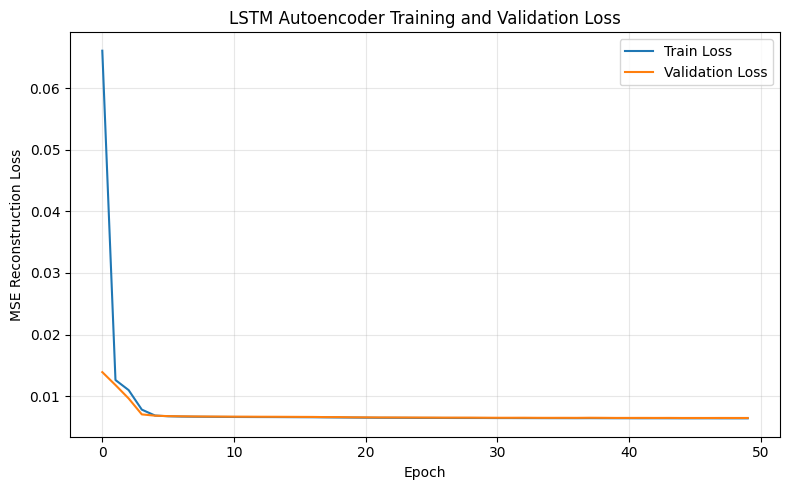

In [69]:


plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss") #for MSE
#plt.ylabel("L1 Reconstruction Loss") #for L!
plt.title("LSTM Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_training_curve.png"), dpi=300)
plt.show()

In [53]:


X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)
eval_dataset = TensorDataset(X_eval_tensor)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

reconstruction_errors = []
reconstructed_sequences = []

model.eval()

with torch.no_grad():
    for (X_batch,) in eval_loader:
        X_batch = X_batch.to(device)

        reconstructed = model(X_batch)

        #batch_errors = torch.mean(torch.abs(X_batch - reconstructed), dim=(1, 2)) #for l1
        batch_errors = torch.mean((X_batch - reconstructed) ** 2,dim=(1, 2)) #for mse
        reconstruction_errors.extend(batch_errors.cpu().numpy())
        reconstructed_sequences.append(reconstructed.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
reconstructed_sequences = np.concatenate(reconstructed_sequences, axis=0)

print("Reconstruction errors:", reconstruction_errors.shape)
print("Reconstructed sequences:", reconstructed_sequences.shape)

Reconstruction errors: (4259,)
Reconstructed sequences: (4259, 30, 15)


In [54]:

healthy_errors = reconstruction_errors[y_eval == 0]
anomalous_errors = reconstruction_errors[y_eval == 1]

print("Evaluation healthy mean error:", healthy_errors.mean())
print("Evaluation healthy std error:", healthy_errors.std())

print("Evaluation anomalous mean error:", anomalous_errors.mean())
print("Evaluation anomalous std error:", anomalous_errors.std())

print("Evaluation healthy median error:", np.median(healthy_errors))
print("Evaluation anomalous median error:", np.median(anomalous_errors))

Evaluation healthy mean error: 0.0065870252
Evaluation healthy std error: 0.0032791945
Evaluation anomalous mean error: 0.011006391
Evaluation anomalous std error: 0.0056402823
Evaluation healthy median error: 0.0047215675
Evaluation anomalous median error: 0.009349279


In [55]:


THRESHOLD_PERCENTILE = 95

val_errors = []

model.eval()
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)

        reconstructed = model(X_batch)

       # batch_errors = torch.mean(torch.abs(X_batch - reconstructed),dim=(1, 2)) #for l1
        batch_errors = torch.mean((X_batch - reconstructed) ** 2,dim=(1, 2)) #for mse

        val_errors.extend(batch_errors.cpu().numpy())

val_errors = np.array(val_errors)

threshold = np.percentile(val_errors, THRESHOLD_PERCENTILE)

y_pred = (reconstruction_errors > threshold).astype(int)

precision = precision_score(y_eval, y_pred, zero_division=0)
recall = recall_score(y_eval, y_pred, zero_division=0)
f1 = f1_score(y_eval, y_pred, zero_division=0)
auc = roc_auc_score(y_eval, reconstruction_errors)
cm = confusion_matrix(y_eval, y_pred)

print(f"Threshold percentile: {THRESHOLD_PERCENTILE}")
print(f"Threshold value from validation set: {threshold:.6f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")
print("Confusion matrix:")
print(cm)

Threshold percentile: 95
Threshold value from validation set: 0.013306
Precision: 0.9136
Recall: 0.2661
F1-score: 0.4122
ROC AUC: 0.7897
Confusion matrix:
[[1081   78]
 [2275  825]]


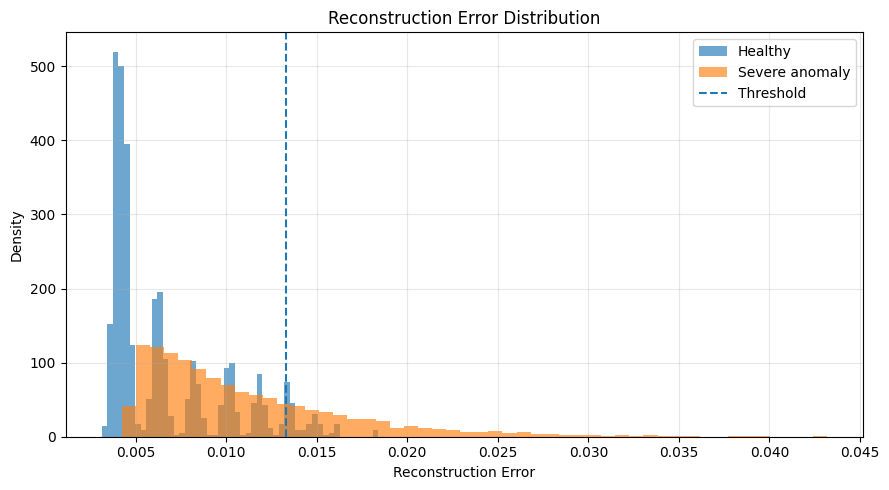

In [56]:


plt.figure(figsize=(9, 5))
plt.hist(healthy_errors, bins=50, alpha=0.65, label="Healthy", density=True)
plt.hist(anomalous_errors, bins=50, alpha=0.65, label="Severe anomaly", density=True)

plt.axvline(threshold, linestyle="--", label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_error_distribution.png"), dpi=300)
plt.show()

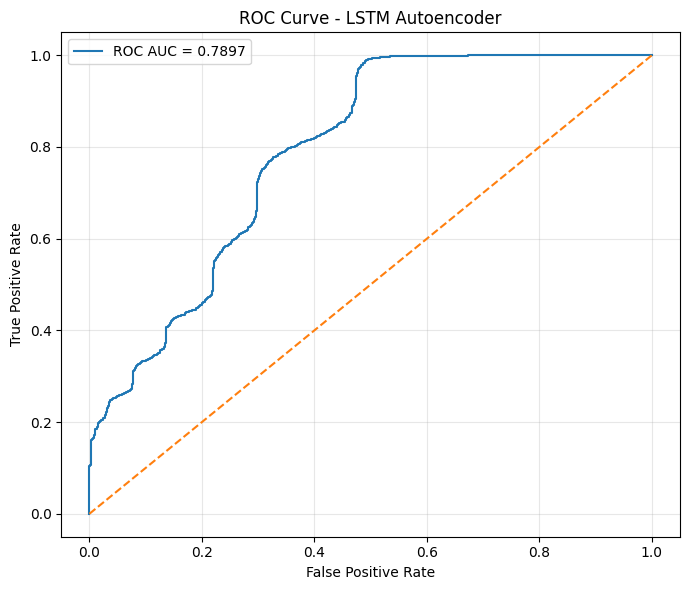

In [57]:


fpr, tpr, roc_thresholds = roc_curve(y_eval, reconstruction_errors)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_roc_curve.png"), dpi=300)
plt.show()

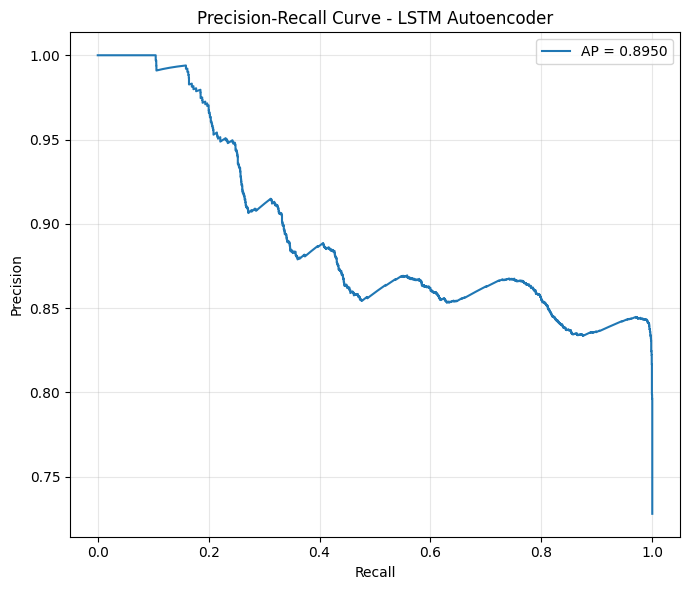

In [58]:


pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_eval,
    reconstruction_errors
)

avg_precision = average_precision_score(y_eval, reconstruction_errors)

plt.figure(figsize=(7, 6))
plt.plot(pr_recall, pr_precision, label=f"AP = {avg_precision:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - LSTM Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_precision_recall_curve.png"), dpi=300)
plt.show()

In [59]:


summary_path = os.path.join(
    RESULTS_DIR,
    "autoencoder_metrics_summary.csv"
)

summary_row = {
    "experiment": EXPERIMENT_NAME,
    "seq_length": SEQ_LENGTH,
    "hidden_size": HIDDEN_SIZE,
    "loss": "MSE",
    "denoising": DENOISING,
    "noise_factor": NOISE_FACTOR,
    "threshold_percentile": THRESHOLD_PERCENTILE,
    "threshold": threshold,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": auc,
    "average_precision": avg_precision,
    "healthy_mean_error": healthy_errors.mean(),
    "anomalous_mean_error": anomalous_errors.mean()
}

new_row_df = pd.DataFrame([summary_row])

if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    summary_df = summary_df[summary_df["experiment"] != EXPERIMENT_NAME]
    summary_df = pd.concat([summary_df, new_row_df], ignore_index=True)
else:
    summary_df = new_row_df

summary_df = summary_df.sort_values(
    "roc_auc",
    ascending=False
).reset_index(drop=True)

summary_df.to_csv(summary_path, index=False)

metrics_path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_metrics.csv")
new_row_df.to_csv(metrics_path, index=False)

summary_df

,experiment,seq_length,hidden_size,loss,threshold_percentile,precision,recall,f1,roc_auc,average_precision,healthy_mean_error,anomalous_mean_error,denoising,noise_factor,threshold
0,lstm_autoencoder_strict_hidden32_l1,30,32,L1,95,0.972222,0.903226,0.936455,0.983657,0.993945,0.049432,0.095966,0.0,0.00,0.057818
1,lstm_autoencoder_strict_hidden32_l1_denoising,30,32,L1,95,0.971449,0.889032,0.928415,0.980547,0.992773,0.049312,0.092922,1.0,0.01,0.057634
2,lstm_autoencoder_strict_hidden16_l1,30,16,L1,95,0.971325,0.863226,0.914091,0.975362,0.990752,0.049452,0.087457,0.0,0.00,0.057783
3,lstm_autoencoder_strict_hidden32_mse,30,32,MSE,95,0.913621,0.266129,0.412191,0.789735,0.895000,0.006587,0.011006,0.0,0.00,0.013306


In [60]:

percentiles = [80, 85, 90, 92, 95, 97, 99]

threshold_results = []

for p in percentiles:
    current_threshold = np.percentile(val_errors, p)
    current_pred = (reconstruction_errors > current_threshold).astype(int)

    threshold_results.append({
        "percentile": p,
        "threshold": current_threshold,
        "precision": precision_score(y_eval, current_pred, zero_division=0),
        "recall": recall_score(y_eval, current_pred, zero_division=0),
        "f1": f1_score(y_eval, current_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,percentile,threshold,precision,recall,f1
0,80,0.008937,0.866632,0.534516,0.661213
1,85,0.010173,0.871713,0.438387,0.583387
2,90,0.011844,0.893311,0.340323,0.492875
3,92,0.012067,0.907540,0.326129,0.479829
4,95,0.013306,0.913621,0.266129,0.412191
5,97,0.013682,0.943971,0.250000,0.395307
6,99,0.015124,0.972492,0.193871,0.323292


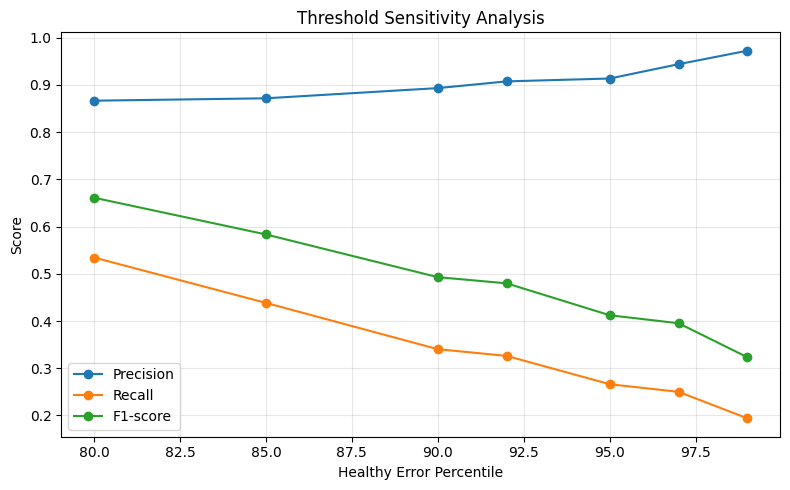

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="F1-score")

plt.xlabel("Healthy Error Percentile")
plt.ylabel("Score")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_threshold_sensitivity.png"), dpi=300)
plt.show()

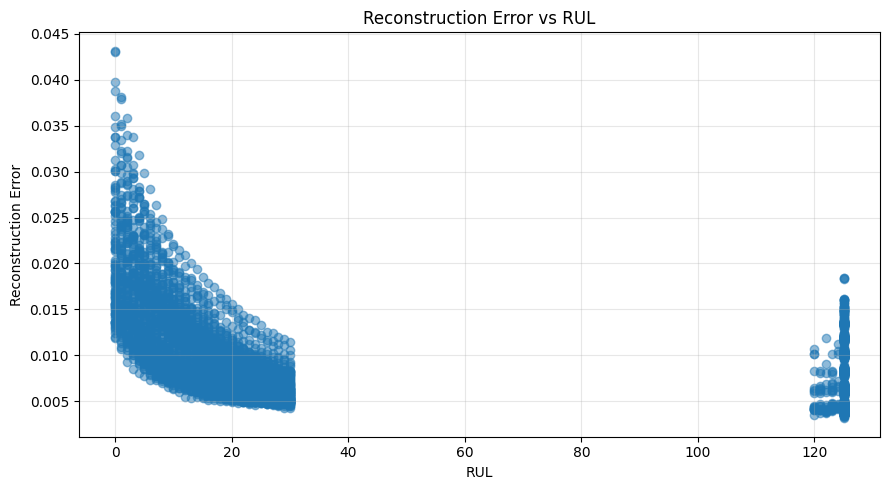

In [62]:

plt.figure(figsize=(9, 5))
plt.scatter(rul_eval, reconstruction_errors, alpha=0.5)

plt.xlabel("RUL")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs RUL")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_error_vs_rul.png"), dpi=300)
plt.show()

In [63]:


analysis_df = pd.DataFrame({
    "unit": unit_eval,
    "cycle": cycle_eval,
    "rul": rul_eval,
    "label": y_eval,
    "reconstruction_error": reconstruction_errors,
    "predicted_label": y_pred
})

bins = [0, 10, 20, 30, 60, 90, 120, 200]
bin_labels = ["0-10", "10-20", "20-30", "30-60", "60-90", "90-120", "120+"]

analysis_df["rul_range"] = pd.cut(
    analysis_df["rul"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)

rul_error_summary = analysis_df.groupby("rul_range", observed=False).agg(
    mean_error=("reconstruction_error", "mean"),
    std_error=("reconstruction_error", "std"),
    samples=("reconstruction_error", "count")
).reset_index()

rul_error_summary

,rul_range,mean_error,std_error,samples
0,0-10,0.015980,0.006012,1100
1,10-20,0.009613,0.003128,1000
2,20-30,0.006929,0.001829,1000
3,30-60,NaN,NaN,0
4,60-90,NaN,NaN,0
5,90-120,0.005768,0.002342,19
6,120+,0.006601,0.003293,1140


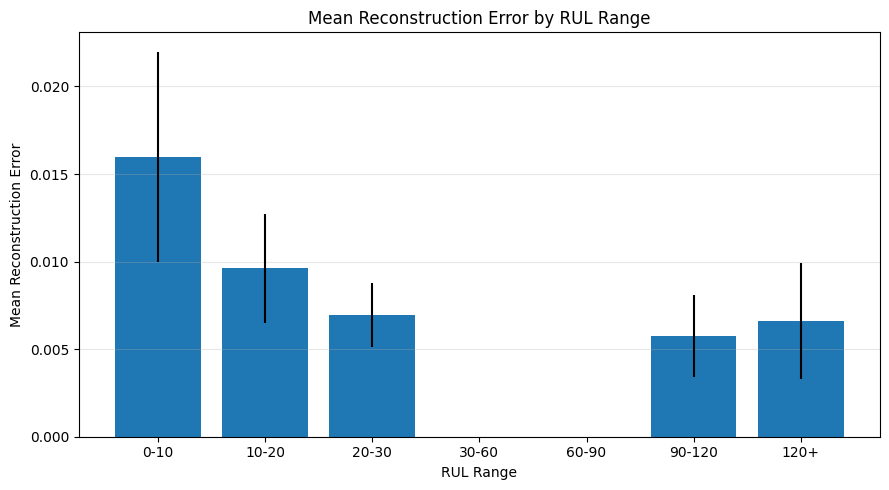

In [64]:
plt.figure(figsize=(9, 5))
plt.bar(
    rul_error_summary["rul_range"].astype(str),
    rul_error_summary["mean_error"],
    yerr=rul_error_summary["std_error"]
)

plt.xlabel("RUL Range")
plt.ylabel("Mean Reconstruction Error")
plt.title("Mean Reconstruction Error by RUL Range")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_mean_error_by_rul_range.png"), dpi=300)
plt.show()

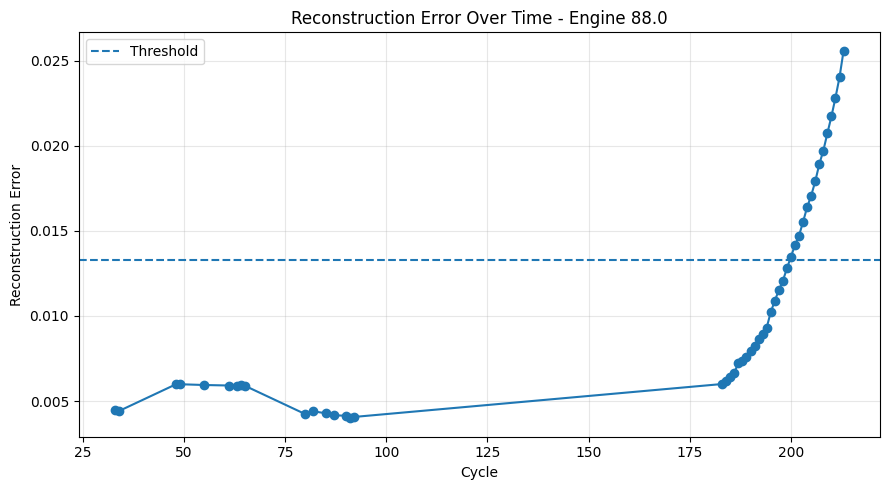

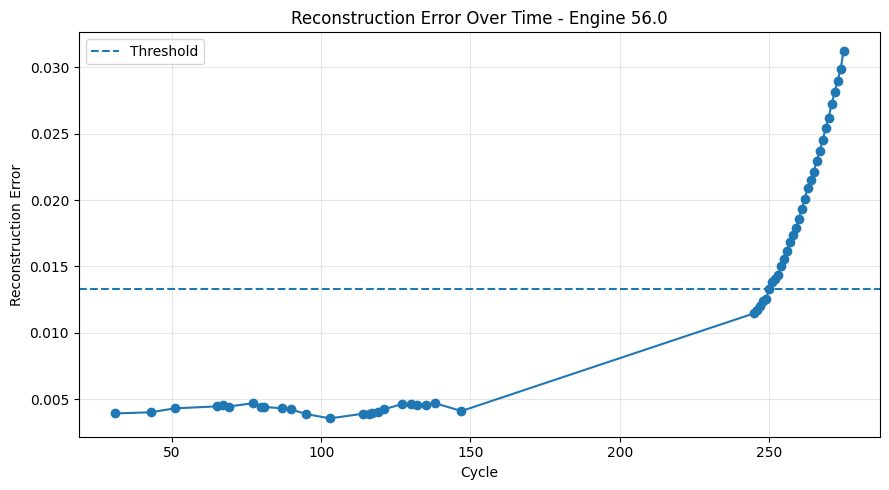

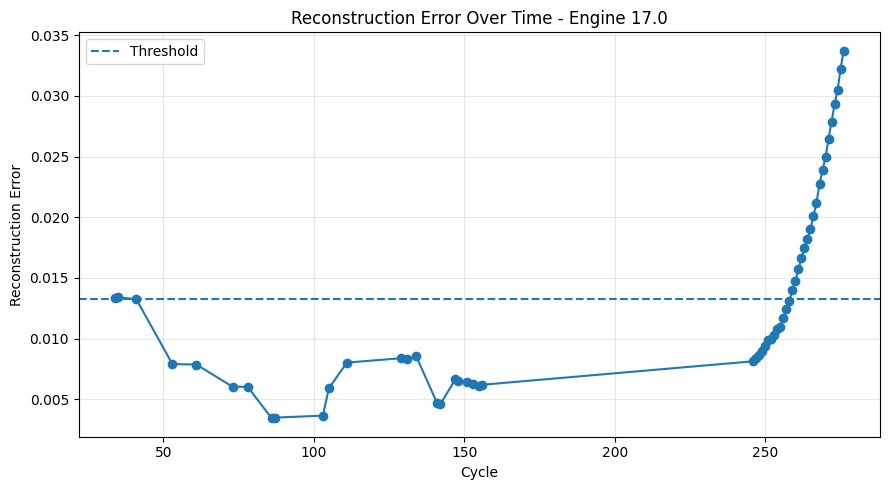

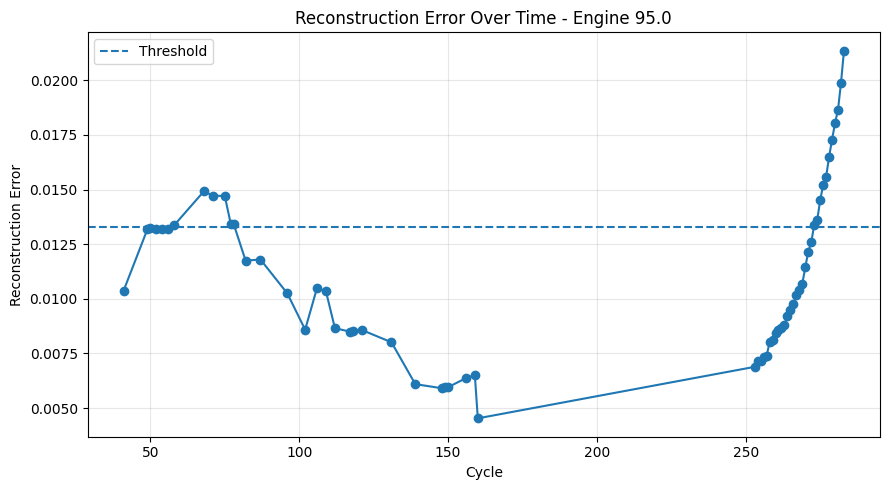

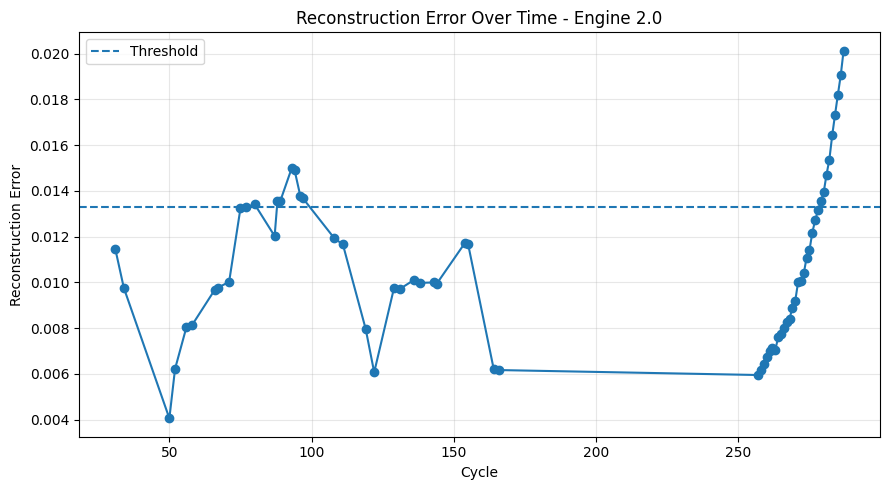

In [65]:


selected_units = analysis_df["unit"].unique()[:5]

for unit in selected_units:
    unit_df = analysis_df[analysis_df["unit"] == unit].sort_values("cycle")

    plt.figure(figsize=(9, 5))
    plt.plot(unit_df["cycle"], unit_df["reconstruction_error"], marker="o")
    plt.axhline(threshold, linestyle="--", label="Threshold")

    plt.xlabel("Cycle")
    plt.ylabel("Reconstruction Error")
    plt.title(f"Reconstruction Error Over Time - Engine {unit}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_engine_{unit}_error_over_time.png"),
        dpi=300
    )
    plt.show()

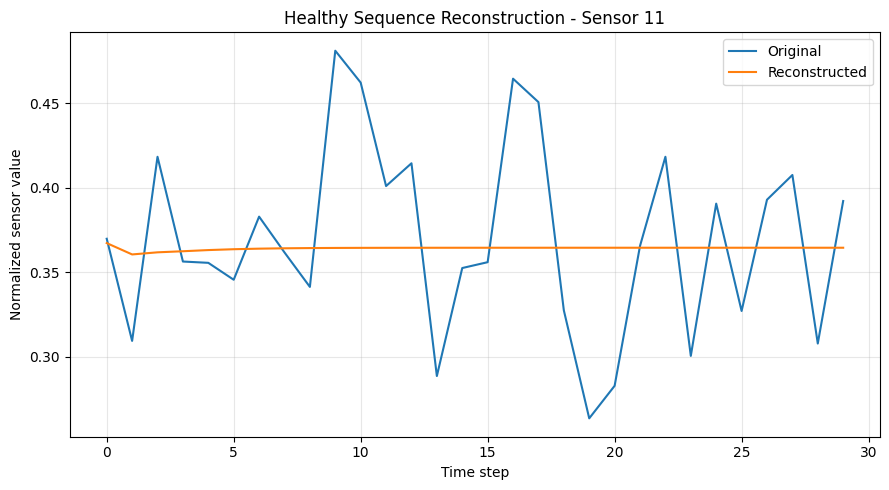

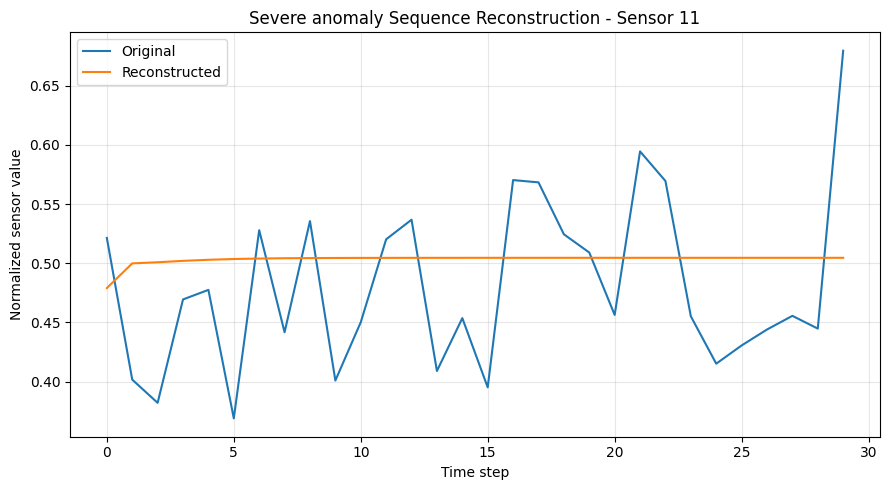

In [66]:


healthy_indices = np.where(y_eval == 0)[0]
anomaly_indices = np.where(y_eval == 1)[0]

healthy_example_idx = healthy_indices[0]
anomaly_example_idx = anomaly_indices[0]

sensor_idx = 11

examples = [
    ("Healthy", healthy_example_idx),
    ("Severe anomaly", anomaly_example_idx)
]

for title, idx in examples:
    plt.figure(figsize=(9, 5))

    plt.plot(X_eval[idx, :, sensor_idx], label="Original")
    plt.plot(reconstructed_sequences[idx, :, sensor_idx], label="Reconstructed")

    plt.xlabel("Time step")
    plt.ylabel("Normalized sensor value")
    plt.title(f"{title} Sequence Reconstruction - Sensor {sensor_idx}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOTS_DIR, f"{EXPERIMENT_NAME}_{title.lower().replace(' ', '_')}_reconstruction.png"),
        dpi=300
    )
    plt.show()

In [67]:


analysis_df.to_csv(
    os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_detailed_results.csv"),
    index=False
)

threshold_df.to_csv(
    os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_threshold_sensitivity.csv"),
    index=False
)

rul_error_summary.to_csv(
    os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_error_by_rul_range.csv"),
    index=False
)

np.save(
    os.path.join(PROCESSED_DIR, f"{EXPERIMENT_NAME}_reconstruction_errors.npy"),
    reconstruction_errors
)

np.save(
    os.path.join(PROCESSED_DIR, f"{EXPERIMENT_NAME}_y_eval.npy"),
    y_eval
)

print("All results saved.")

All results saved.


In [68]:
model_path = os.path.join(MODELS_DIR, f"{EXPERIMENT_NAME}.pt")

torch.save({
    "model_state_dict": best_model_state,
    "n_features": N_FEATURES,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "seq_length": SEQ_LENGTH,
    "threshold": threshold,
    "threshold_percentile": THRESHOLD_PERCENTILE,
    "loss": "MSE",
    "denoising": DENOISING,
    "noise_factor": NOISE_FACTOR
}, model_path)

print("Best model saved to:", model_path)

Best model saved to: ../models/lstm_autoencoder_strict_hidden32_mse.pt
